# Download, extract, & prep mcool files

In [ ]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K

filenames=$(for each in Oligo_NN L6_CT_CTX_Glut Astro-TE_NN L2_3_IT_CTX_Glut Endo_NN L4_5_IT_CTX_Glut L5_IT_CTX_Glut L6_IT_CTX_Glut; do ls $each*; done)

mkdir originals
mv *.mcool originals/
mkdir selected && cd selected


for each in $filenames; do
	echo -e "\n======== $each"
	cooler cp ../originals/$each::/resolutions/100000 $each::/resolutions/100000 && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n\n======== $each"
	cooler coarsen -k 25 $each::/resolutions/100000 -o $each::/resolutions/2500000 -a && echo && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n======== $each"
	cooler balance $each::/resolutions/2500000 --cis-only --convergence-policy 'discard' 
done


# for each in $filenames; do
# 	echo -e "\n$each"
# 	cooler ls $each
# done


# Distance decay - mcool files

In [ ]:
%load_ext autoreload
%autoreload 2 

In [ ]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [ ]:
resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)

In [ ]:
# get centromere data from ucsc gap file
mm10_gap = pd.read_csv(
    '/net/gs/vol1/home/gesine/noble_lab/resources/genomic/gaps/ucsc.mm10.gap.txt',
    sep='\t', header=None, names=(
        'bin', 'chrom', 'start', 'end', 'ix', 'n', 'size', 'type', 'bridge'))
mm10_cens = mm10_gap.loc[mm10_gap.type == 'centromere', ['chrom', 'start', 'end']].copy().reset_index()
mm10_cens['mid'] = ((mm10_cens.start + mm10_cens.end) / 2).astype(int)
# Use bioframe to fetch the genomic features from the UCSC.
mm10_chromsizes = bioframe.fetch_chromsizes('mm10')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
mm10_arms = bioframe.make_chromarms(mm10_chromsizes,  mm10_cens)
# remove chrX, chrY, chrM
mm10_arms = mm10_arms[~mm10_arms.chrom.isin(['chrX', 'chrY', 'chrM'])].reset_index(drop=True)
# remove arms that are less than the current binsize/resolution
mm10_arms = mm10_arms[(mm10_arms.end - mm10_arms.start) > resolution]

In [ ]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/L2_3_IT_CTX_Glut.Raw.100K.mcool'
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/L2_3_IT_CTX_Glut.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'

resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
uri = f'{mcool_file}::/resolutions/{resolution:d}'

print(uri)
clr = cooler.Cooler(uri)

cis_cov, tot_cov = cooltools.coverage(clr, ignore_diags=1, nproc=2)
print(f"nreads: {cis_cov.sum():,}", flush=True)

In [ ]:
cvd_smooth_agg = cooltools.expected_cis(
    clr=clr,
    view_df= mm10_arms[mm10_arms.chrom.isin(clr.chromnames)].reset_index(drop=True),
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus,
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

# Idk

## Load

In [142]:
import pandas as pd
import glob
import os
import ast
import numpy as np
from cooltools.sandbox.expected_smoothing import log_smooth

import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import seaborn as sns


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'


sc_dis_intramol_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.intramol.tsv.gz'))
if len(sc_dis_intramol_file) != 1:
    raise ValueError("Couldn't find unique file for intra-mol single cell distances")
sc_dis_intramol_file = sc_dis_intramol_file[0]

sc_dis_intramol = pd.read_csv(
    sc_dis_intramol_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})

## Analyze

In [222]:
dis_exp = -1; sigma_log10 = 0.01  # 1/exp = 4.9;   1/exp * dis_exp = 4.9;  alpha = -7.6
dis_exp = -3; sigma_log10 = 0.2   # 1/exp = ~2;    1/exp * dis_exp = 6;    alpha = 6 * -1.55 = -9.3
dis_exp = -0.5; sigma_log10 = 0.1   # 1/exp = 10;  1/exp * dis_exp = 5;    alpha = -7.5
dis_exp = -5; sigma_log10 = 0.1   # 1/exp =  2;  1/exp * dis_exp =  10;    alpha =  -15
dis_exp = 1; sigma_log10 = 0.1  # 1/exp = 5.38;                           alpha = -8.34
dis_exp = -1; sigma_log10 = 0.1  # 1/exp = 4.9;   1/exp * dis_exp = 4.9;  alpha = -7.7

by_genomic_dis = prep_invdis_by_genomic_dist(sc_dis_intramol, dis_exp=dis_exp)
by_genomic_dis_smooth = smooth_frequency(by_genomic_dis, sigma_log10=sigma_log10)
# by_genomic_dis_smooth.head(3)

In [353]:
bgd_mask = by_genomic_dis[by_genomic_dis.index.get_level_values(1) == 'n'].values < 19


33.368374847166535 11.0 42.5140902154175 19.0


(np.float64(555.0), np.float64(0.0))

In [355]:
by_genomic_dis_smooth.n[by_genomic_dis_smooth.n != 0].describe()

count    220827.000000
mean         42.514090
std          58.878845
min           1.000000
25%           7.000000
50%          19.000000
75%          53.000000
max         555.000000
Name: n, dtype: float64

In [360]:
print((by_genomic_dis_smooth.smoothed_n > by_genomic_dis_smooth.n).sum() / len(by_genomic_dis_smooth))
m = by_genomic_dis_smooth.n != 0
print((by_genomic_dis_smooth[m].smoothed_n > by_genomic_dis_smooth[m].n).sum() / m.sum())

0.5388339162330461
0.4143198069076698


### Get exponent per cell

In [336]:
def get_exponent_per_cell(df, dis_exp):
    genomic_dis = df.index.values
    freq_smooth = df.smoothed_freq.values.ravel()
    
    d = estimate_exponent(genomic_dis, freq_smooth=freq_smooth, verbose=False)
    # d = estimate_exponent(
    #     genomic_dis, freq_smooth=freq_smooth, x0=x0, bounds=bounds, seed=seed,
    #     max_iter=max_iter, verbose=False)

    v = d['exponent'] / dis_exp
    detected_genomic_dis = s = df[df.n > 0].index.values
    res = {'v': v, 'n_sum': df.n.sum(), 's_size': int(s.size), 's_mean': s.mean(), 's_median': np.median(s), 's_range': int(s.max() - s.min() + 1)}
    return pd.Series(res)


min_genomic_dis = None; max_genomic_dis = 'default'

if min_genomic_dis is None:
    min_genomic_dis = by_genomic_dis_smooth.index.min()
if max_genomic_dis is None:
    max_genomic_dis = by_genomic_dis_smooth.index.max()
elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
    max_genomic_dis = 6e7
mask = (by_genomic_dis_smooth.index <= max_genomic_dis) & (by_genomic_dis_smooth.index >= min_genomic_dis)

# tmp = by_genomic_dis_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
# n_sum = by_genomic_dis_smooth[mask].groupby('cell_num').n.sum().to_frame().rename({'n': 'n_sum'}, axis=1)
# per_cell = pd.concat([n_sum, tmp.to_frame().rename({0: 'v'}, axis=1)], axis=1)

per_cell = by_genomic_dis_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
per_cell['s_range'] = per_cell.s_range.astype(int)
per_cell['s_size'] = per_cell.s_size.astype(int)

In [342]:
per_cell

,v,n_sum,s_size,s_mean,s_median,s_range
cell_num,,,,,,
1,0.375015,625.0,57,29.315789,29.0,59
2,0.075970,2962.0,61,31.000000,31.0,61
3,0.285162,171.0,42,21.500000,21.5,42
4,0.285614,3822.0,72,36.500000,36.5,72
5,0.088140,1713.0,72,36.569444,36.5,73
...,...,...,...,...,...,...
3698,0.184847,973.0,65,33.030769,33.0,66
3699,0.213702,1564.0,59,30.000000,30.0,59
3700,0.181283,1002.0,52,26.653846,26.5,56


In [320]:
min_nsum = 2500

display(per_cell.describe())
print('\ns < -0.25')
display(per_cell[per_cell.v < -0.25].describe())
print(f'\nn_sum > {min_nsum}')
display(per_cell[per_cell.n_sum >= min_nsum].describe())

pairs_per_cell = by_genomic_dis_smooth[mask].groupby('cell_num').n.sum()
cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
num_pairs_orig = sc_dis_intramol.notnull().values.sum()
num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs")

,n_sum,s
count,3702.000000,3702.000000
mean,2535.996488,0.152519
std,2584.415460,0.335538
min,28.000000,-2.739234
25%,630.000000,0.150306
50%,1550.000000,0.193780
75%,3629.000000,0.234345
max,14663.000000,0.663024



s < -0.25


,n_sum,s
count,53.000000,53.000000
mean,106.660377,-2.444877
std,108.888253,0.769211
min,28.000000,-2.739234
25%,55.000000,-2.739234
50%,78.000000,-2.739234
75%,105.000000,-2.739234
max,631.000000,-0.261945



n_sum > 2500


,n_sum,s
count,1333.000000,1333.000000
mean,5302.032258,0.197691
std,2413.354749,0.040951
min,2504.000000,0.027255
25%,3385.000000,0.172482
50%,4638.000000,0.198055
75%,6536.000000,0.224052
max,14663.000000,0.323551


Retaining 75% of pairs


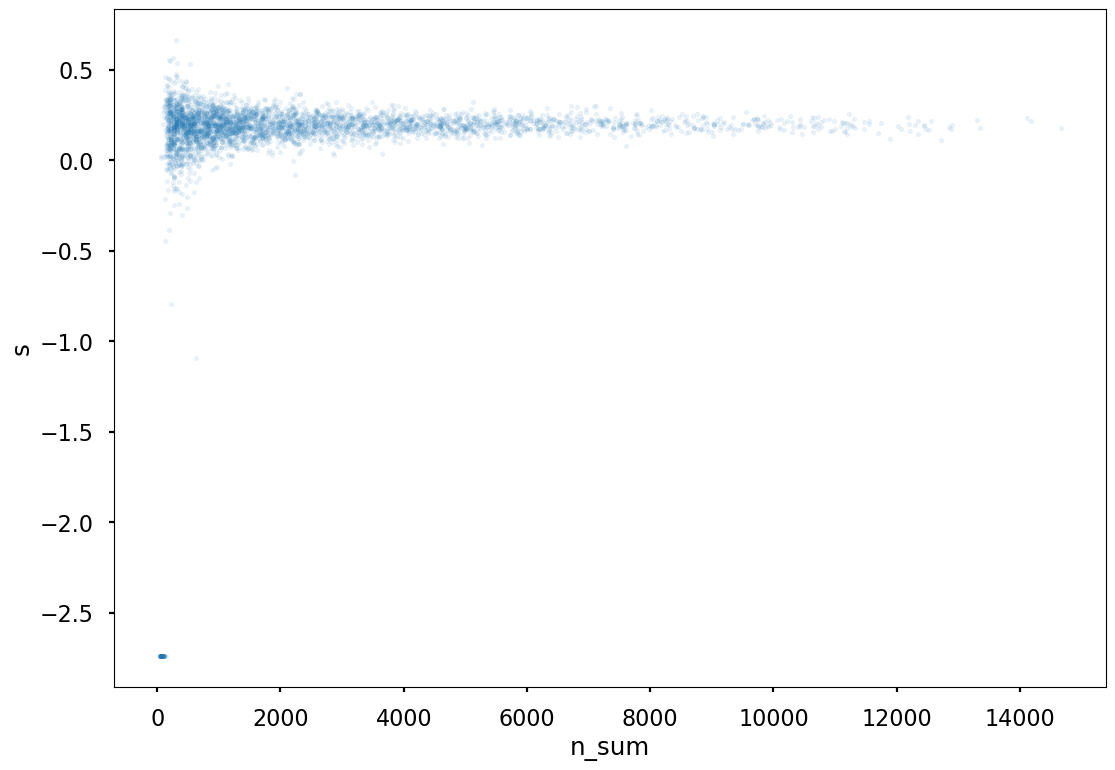

In [252]:
sns.scatterplot(data=per_cell, x="n_sum", y="v", s=10, alpha=0.1, edgecolors=None)  # 
plt.show()

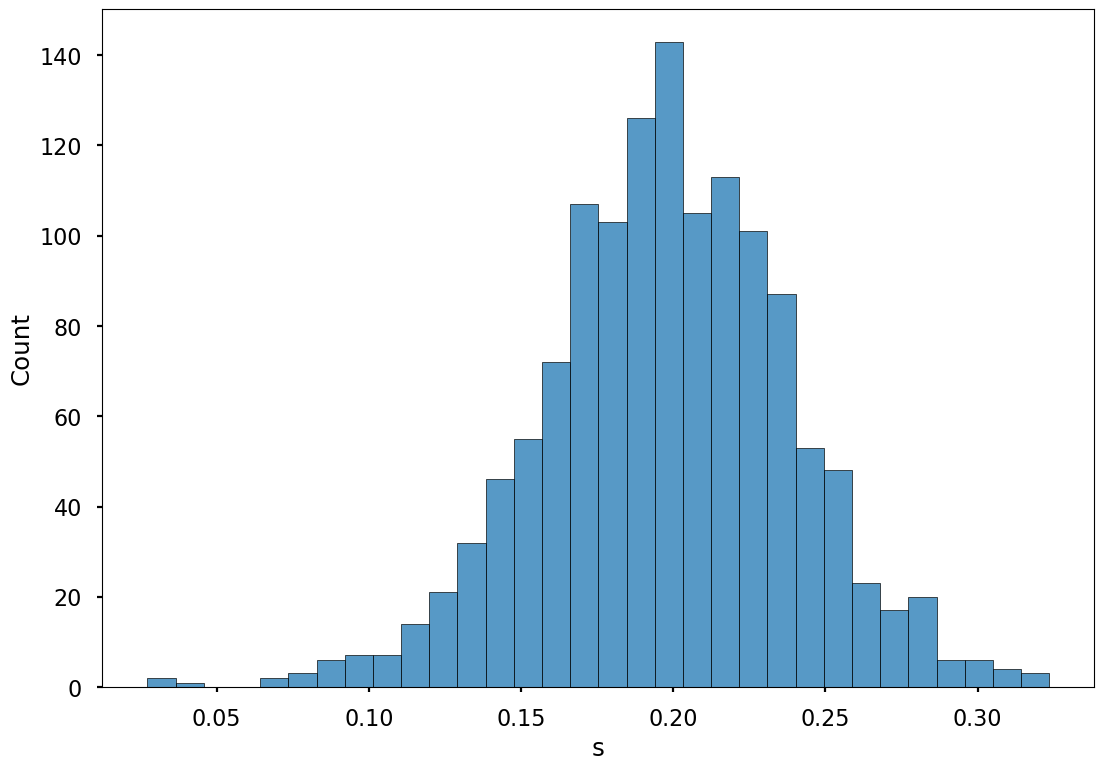

In [326]:
sns.histplot(data=per_cell[per_cell.n_sum > 2500], x="v")
plt.show()

## Plot

In [365]:
by_genomic_dis_smooth[by_genomic_dis_smooth.n < 19]

,data,n,smoothed_data,smoothed_n,smoothed_freq,cell_num
genomic_dis,,,,,,
10,17.354221,17,22.349328,19.868548,1.124860,1
13,15.943054,15,18.342647,18.130884,1.011680,1
14,20.499217,18,17.290678,17.700721,0.976835,1
17,14.837885,17,14.440154,16.343472,0.883543,1
18,15.884474,17,13.552743,15.816838,0.856855,1
...,...,...,...,...,...,...
72,0.289883,1,5.620179,7.591269,0.740348,3702
73,0.000000,0,5.312256,7.181827,0.739680,3702
74,0.000000,0,5.025417,6.802286,0.738784,3702


Retaining 100% of pairs


s = 0.203
1/s = 4.94
est alpha = b/s = -7.65


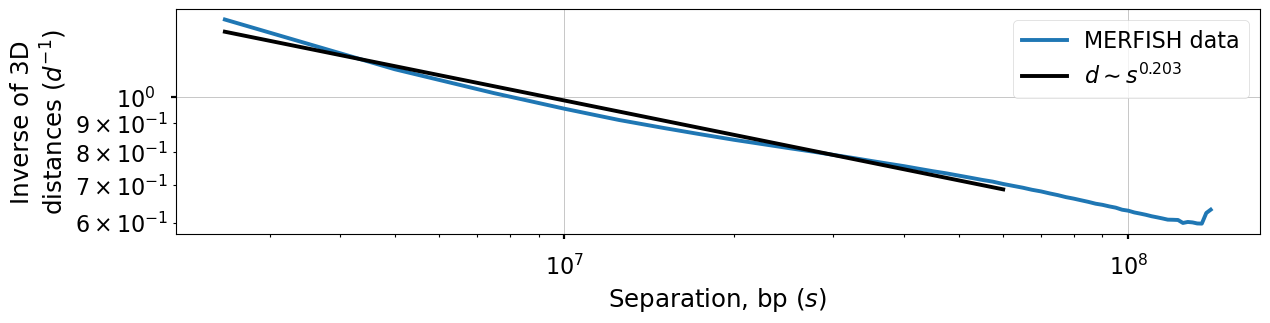

s = 0.2
1/s = 5
est alpha = b/s = -7.75


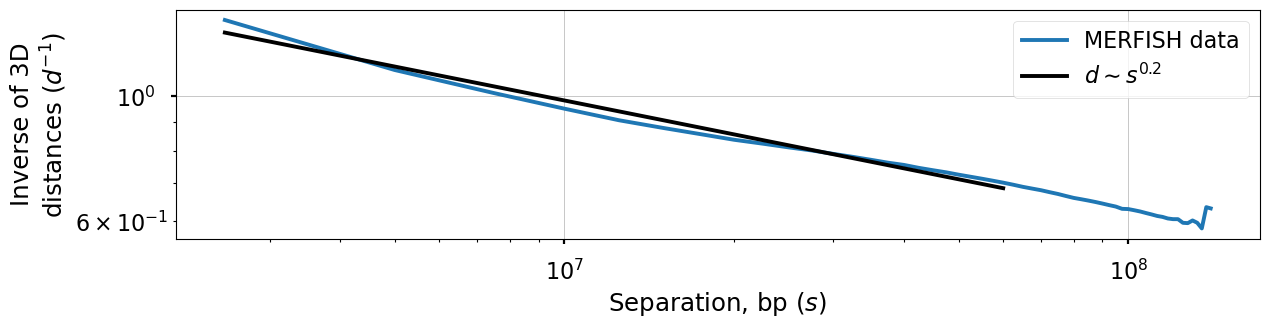

s = 0.203
1/s = 4.93
est alpha = b/s = -7.63


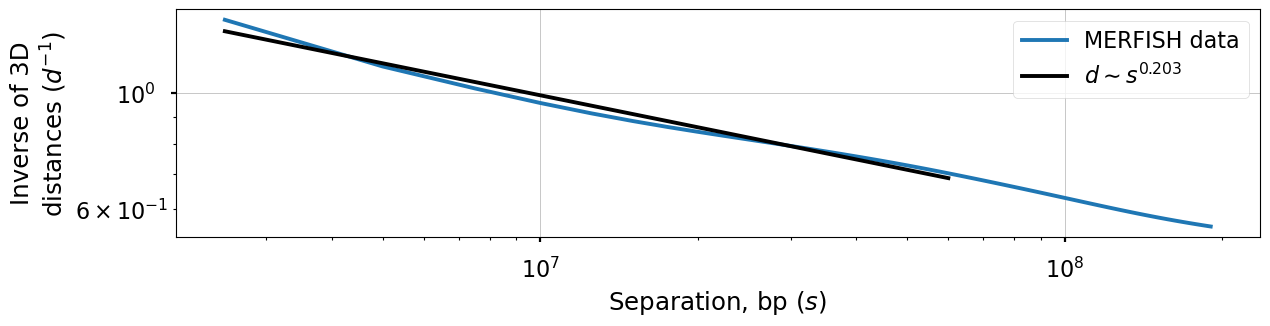

s = 0.203
1/s = 4.93
est alpha = b/s = -7.63


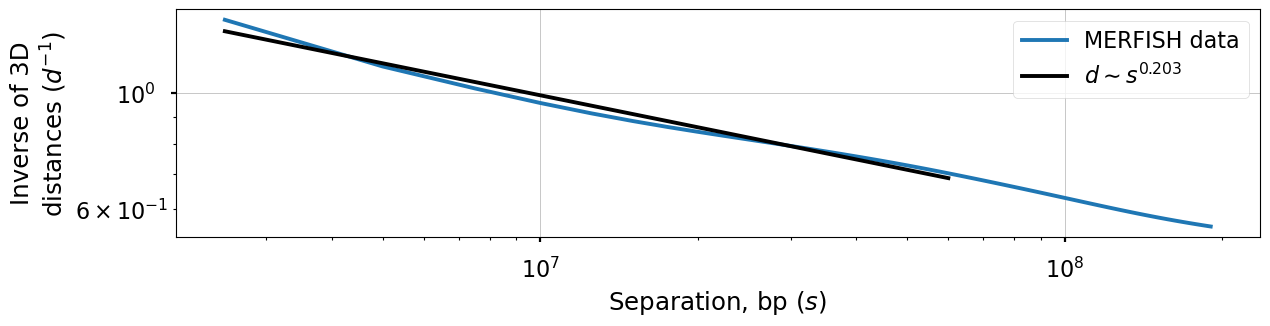

In [366]:
min_nsum = 5

pairs_per_cell = by_genomic_dis_smooth[mask].groupby('cell_num').n.sum()
cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
num_pairs_orig = sc_dis_intramol.notnull().values.sum()
num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs\n\n")

data_smooth = by_genomic_dis_smooth[by_genomic_dis_smooth.cell_num.isin(cells_to_use)].copy()
data_orig = by_genomic_dis[cells_to_use]

data_smooth[data_smooth.n < 40] = np.nan

by_genomic_dis_smooth_mean = data_smooth.groupby(level=0).mean().drop('cell_num', axis=1)
# display(by_genomic_dis_smooth_mean.head(2)); display(by_genomic_dis_smooth_mean.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(by_genomic_dis_smooth_mean, seed=0, dis_exp=dis_exp, verbose=True)

by_genomic_dis_smooth_med = data_smooth.groupby(level=0).median().drop('cell_num', axis=1)
# display(by_genomic_dis_smooth_med.head(2)); display(by_genomic_dis_smooth_med.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(by_genomic_dis_smooth_med, seed=0, dis_exp=dis_exp, verbose=True)

by_genomic_dis_sum = data_orig.sum(axis=1).to_frame().rename({0: 'sc_sum'}, axis=1)
by_genomic_dis_sum_smooth = smooth_frequency(by_genomic_dis_sum, sigma_log10=0.1)
# display(by_genomic_dis_sum_smooth.head(2)); display(by_genomic_dis_sum_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(by_genomic_dis_sum_smooth, seed=0, dis_exp=dis_exp, verbose=True)


by_genomic_dis_med = data_orig.median(axis=1).to_frame().rename({0: 'sc_median'}, axis=1)
by_genomic_dis_med_smooth = smooth_frequency(by_genomic_dis_sum, sigma_log10=0.1)
# display(by_genomic_dis_med_smooth.head(2)); display(by_genomic_dis_med_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(by_genomic_dis_med_smooth, seed=0, dis_exp=dis_exp, verbose=True)

# Fxn

In [273]:
n = 11
x_true = np.triu(np.ones((n, n)), 1).sum()
x = (n ** 2 - n) / 2
n_result = int((1 + np.sqrt(1 + 8 * x)) / 2)
print(x_true, x)
print(n, n_result)

55.0 55.0
11 11


In [211]:
def agg_across_genomic_dist(df):
    n_detected_sum = df.notnull().sum(axis=0)
    n_detected_sum.name = 'n'
    data_sum = df.sum(axis=0)
    data_sum.name = 'data'

    agg = pd.concat([
        data_sum.to_frame().T, n_detected_sum.to_frame().T])
    agg.index.name
    return agg


def prep_invdis_by_genomic_dist(sc_dis_intramol, dis_exp=-1):
    sc_invdis_intramol = sc_dis_intramol.pow(dis_exp)
    sc_invdis_intramol.index = [j - i for i, j in sc_invdis_intramol.index]
    sc_invdis_intramol.columns.name = 'genomic_dis'
    sc_invdis_intramol.sort_index(inplace=True)
    by_genomic_dis = sc_invdis_intramol.groupby(level=0).apply(agg_across_genomic_dist)
    by_genomic_dis.index.names = ['genomic_dis', 'desc']
    return by_genomic_dis

In [130]:
def smooth_frequency(df_freq, sigma_log10=0.1):
    df_freq_smooth = []
    
    for col in df_freq.columns:
        cell_data = df_freq[col].unstack()
        cell_data.columns.name = None
    
        smoothed_data, smoothed_n = log_smooth(
            cell_data.index.values.astype(np.float64),
            cell_data[['data', 'n']].values.T,
            sigma_log10=sigma_log10,
            window_sigma=5, points_per_sigma=10)
    
        
        cell_data['smoothed_data'] = smoothed_data
        cell_data['smoothed_n'] = smoothed_n
        cell_data['smoothed_freq'] = np.nan
        mask = smoothed_n != 0
        # if np.any(~mask) and np.any(smoothed_data[~mask] != 0):
        #     print(col)
        cell_data.loc[mask, 'smoothed_freq'] = smoothed_data[mask] / smoothed_n[mask]
        cell_data['cell_num'] = col
        cell_data['n'] = cell_data['n'].astype(int)
    
        df_freq_smooth.append(cell_data)
    
    df_freq_smooth = pd.concat(df_freq_smooth)
    return df_freq_smooth

In [208]:
def estimate_exponent_manual(by_genomic_dis_smooth_agg, x0=None, bounds=(-10, 10), seed=0,
                             min_genomic_dis=None, max_genomic_dis='default',
                             max_iter=1e20, resolution_bp=2.5e6, verbose=True, plot=True, dis_exp=-1):

    dist_decay = by_genomic_dis_smooth_agg.smoothed_freq.copy()
    dist_decay.index *= int(resolution_bp)
    
    # Build args
    if min_genomic_dis is None:
        min_genomic_dis = dist_decay.index.min()
    if max_genomic_dis is None:
        max_genomic_dis = dist_decay.index.max()
    elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
        max_genomic_dis = 6e7
    mask = (dist_decay.index <= max_genomic_dis) & (dist_decay.index >= min_genomic_dis)
    genomic_dis = dist_decay[mask].index.values
    freq_smooth = dist_decay[mask].values.ravel()

    d = estimate_exponent(
        genomic_dis, freq_smooth=freq_smooth, x0=x0, bounds=bounds, seed=seed,
        max_iter=max_iter, verbose=verbose - 1)

    x = genomic_dis
    y = d['scaling_factor'] * np.power(x, d['exponent'])

    exponent_dis3d = d['exponent'] / dis_exp
    est_alpha = -1.55 / exponent_dis3d
    if verbose:
        if verbose > 1:
            print(flush=True)
        print(f"v = {exponent_dis3d:.3g}")
        print(f"1/v = {1 / exponent_dis3d:.3g}")
        print(f"est alpha = B/v = {est_alpha:.3g}")

    if plot:
        f, ax = plt.subplots(1,1)
        ax.loglog(
            by_genomic_dis_smooth_agg.index.values * 2.5e6,
            by_genomic_dis_smooth_agg.smoothed_freq.values,
            label='MERFISH data')
        ax.set(
            xlabel='Separation, bp ($s$)', 
            ylabel='Inverse of 3D\n' + r'distances $(d^{' + f"{-1:g}" '})$')
        ax.set_aspect(1.0)
        ax.grid(lw=0.5)
        
        ax.loglog(x, y, color='black', label=r"$d \sim s^{" + f"{exponent_dis3d:.3g}" + r"}$")
        ax.set_title(f"")
        plt.legend()
        f.tight_layout()
        plt.show()

    return d, (x, y), est_alpha

In [ ]:
import jax.numpy as jnp
from jax import grad
from scipy import optimize
from estimate_alpha import print_alpha_infer_results


def estimate_scaling_factor(exponent, genomic_dis, freq_smooth):
    y = jnp.power(genomic_dis, exponent)
    scaling_factor = jnp.sum(y * freq_smooth) / jnp.sum(jnp.square(y))
    return scaling_factor


def fit_exponent_obj(exponent, genomic_dis, freq_smooth, scaling_factor):
    y = scaling_factor * jnp.power(genomic_dis, exponent)
    mse = jnp.mean(jnp.square(freq_smooth - y))
    return mse


fit_exponent_grad = grad(fit_exponent_obj)


def obj_wrap(exponent, genomic_dis, freq_smooth):
    scaling_factor = estimate_scaling_factor(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth)
    obj = fit_exponent_obj(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth, scaling_factor=scaling_factor)
    if not isinstance(obj, float) and obj.size > 1:
        obj = sum(obj)
    return obj


def grad_wrap(exponent, genomic_dis, freq_smooth):
    scaling_factor = estimate_scaling_factor(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth)
    return np.array(fit_exponent_grad(exponent, genomic_dis=genomic_dis, freq_smooth=freq_smooth, scaling_factor=scaling_factor)).ravel()


def estimate_exponent(genomic_dis, freq_smooth, x0=None, bounds=(-10, 10), seed=0,
                      max_iter=1e20, verbose=True):
    # Define initial value (x0) and bounds on X
    if x0 is None:
        rng = np.random.default_rng(seed=seed)
        x0 = rng.uniform(low=bounds[0], high=bounds[1])
    x0 = np.array(x0, ndmin=1, copy=None)
    bounds = np.array(bounds, ndmin=2, copy=None).reshape(1, -1)

    # Build args
    args = [genomic_dis, freq_smooth]

    # Optimize
    if verbose:
        print("OPTIMIZING:", flush=True)
    obj = obj_wrap(x0, *args)
    if max_iter == 0:
        X = x0
        d = {'converged': 'N/A', 'obj': obj._value}
    else:
        results = optimize.fmin_l_bfgs_b(
            obj_wrap, x0=x0, fprime=grad_wrap, bounds=bounds, args=args,
            factr=1e-20, maxls=40, pgtol=1e-10, maxiter=int(max_iter)) #, maxfun=max_fun)
        X, obj, d = results
        d['converged'] = d['warnflag'] == 0
        conv_desc = d['task']
        d['obj'] = obj
    if X.size == 1:
        d['exponent'] = X[0]
    else:
        d['exponent'] = X
    d['scaling_factor'] = float(estimate_scaling_factor(X, *args)._value)

    if verbose:
        print("\nRESULTS:", flush=True)
        print_alpha_infer_results(d)

    return d